# run_beta_compute.ipynb
This is meant to be the file that generates results for first beta paper

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import importlib

import beta_compute

from beta_compute import BetaEstimator
importlib.reload(beta_compute)
from beta_compute import BetaEstimator
from tqdm import trange

# import inspect
import pickle as pkl
import os
import time
import mapping_tools as mt
import string

from obspy import read_inventory

# import Client
from obspy.clients.fdsn.client import Client
# import UTCDateTime
from obspy.core.utcdatetime import UTCDateTime

In [2]:
def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    if type(x) is list: x = np.array(x)
    if type(y) is list: y = np.array(y)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

## Program parameters

In [3]:

# Required signal-to-noise ratio
stn_req = 3.0

# Signal-to-noise ratio testing band (Hz)
stn_band = (2.667, 6.0)

f_nyquist = 50.0

# Set paths
p_results_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/p_results/"
s_results_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/s_results/"
p_spectra_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/p_spectra.pkl"
s_spectra_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/s_spectra.pkl"
paper_figure_dir = "/Users/ivandevert/Documents/papers/high_freq_ratio/paper_name_pre_submission/figs/"
inv_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/inv/"

# Location of earthquake catalog containing stress drop estimates
delsig_p_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_p.txt"
delsig_s_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_s.txt"


# Make output directories if they don't exist
for pth in [p_results_dir, s_results_dir, paper_figure_dir, inv_dir]:
    if not os.path.exists(pth): os.makedirs(pth)

# Make sure spectra files exist
assert os.path.exists(p_spectra_path), f"p_spectra.pkl not found at {p_spectra_path}"
# assert os.path.exists(s_spectra_path), f"s_spectra.pkl not found at {s_spectra_path}"

In [4]:
# Load P-wave spectra
print("Loading P-wave spectra...", end='')
t0 = time.time()
full_df_p = pd.read_pickle(p_spectra_path)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(full_df_p):,} records.")

# Remove rows with irrelevant directions
print("Removing directions other than Z...", end='')
t0 = time.time()
filtered_df = full_df_p.copy()
filtered_df['direction'] = filtered_df['stid'].str[-1:]
filtered_df = filtered_df[filtered_df['direction'] == 'Z'].reset_index(drop=True)
filtered_df = filtered_df.drop('direction', axis=1)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(filtered_df):,} records remaining.")


# Get inventories if they do not exist
all_stids = full_df_p['stid'].unique()
# check if inventories exist
iris_client = Client("IRIS")
scedc_client = Client("SCEDC")

starttime = UTCDateTime("2019-07-01")
endtime = UTCDateTime("2019-07-16")

print("Downloading inventories...", end='')
for i in trange(len(all_stids)):
    stid = all_stids[i]
    if not os.path.exists(f"{inv_dir}{stid}.xml"):


        net, sta, loc, chan = stid.split('.')
        try:
            inventory = iris_client.get_stations(
                network=net, station=sta, location=loc, channel=chan,
                starttime=starttime, endtime=endtime, level="response",
                filename=f"{inv_dir}{stid}.xml",
                format="xml")
        except:
            try:
                inventory = scedc_client.get_stations(
                    network=net, station=sta, location=loc, channel=chan,
                    starttime=starttime, endtime=endtime, level="response",
                    filename=f"{inv_dir}{stid}.xml",
                    format="xml")
            except:
                print("Error with ", stid)
print(f"Done. t = {time.time()-t0:,.2f} seconds.")

# Make a copy
df_p = filtered_df.copy()

# Make the frequency array (assumed to be the same for all records)
nf = len(df_p['s2'].values[0])
f = np.linspace(0, f_nyquist, nf)

# Filter out low-STN records
print("Filtering out low-STN records...", end='')
t0 = time.time()
stn_i1 = np.argmin(np.abs(f - stn_band[0]))
stn_i2 = np.argmin(np.abs(f - stn_band[1]))

spectra = df_p[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

noise = df_p[['s1']].values
noise = np.stack(noise.flatten()).astype(float)

# Compute STN
df_p['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# Drop records with low STN
df_p = df_p[df_p['stn'] > stn_req].reset_index(drop=True)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(df_p):,} records remaining.")

# # Construct response dataframe
# print("Loading station responses...", end='')
# dt = 1 / (2.0*f_nyquist)
# nfft = (len(f)-1)*2
# stids = df_p['stid'].unique()
# st_list = []
# resp_list = []
# for i in range(len(stids)):
#     stid = stids[i]

#     resp = read_inventory(f"{inv_dir}{stid}.xml")[0][0][0].response
#     r1, _ = resp.get_evalresp_response(t_samp=dt, nfft=nfft, output="DISP", start_stage=None, end_stage=None)
#     r1[0] = r1[1] # fudge first point to avoid division by zero

#     st_list.append(stid)
#     resp_list.append(np.abs(r1))
# df_resp = pd.DataFrame({'stid': st_list, 'resp': resp_list})
# print(f"Done.")

# # Correct signal to displacement and remove response
# print("Correcting spectra to displacement...", end='')
# t0 = time.time()

# df_p = pd.merge(df_p, df_resp, how='left', on='stid')
# df_p['s2'] = df_p['s2'] / df_p['resp']
# df_p = df_p.drop('resp', axis=1)


p_spectra = df_p[['s2']].values
p_spectra = np.stack(p_spectra.flatten()).astype(float)
print(f"Done. t = {time.time()-t0:,.2f} seconds.")


### OLD WAY
# # Correct signal to displacement
# print("Correcting spectra to displacement...", end='')
# t0 = time.time()
# spectra = df_p[['s2']].values
# spectra = np.stack(spectra.flatten()).astype(float)

# # this is correct, as long as input spectra are native units (HH* = velocity, HN* = acceleration)
# # could be more efficient though
# f_corr = np.copy(f)
# f_corr[0] = f_corr[1] / 2 # fudge first point to avoid division by zero
# df_p['units'] = df_p['stid'].str[-2]
# powers = np.zeros(len(df_p), dtype=int)
# powers[df_p['units'] == 'N'] = -2
# powers[df_p['units'] == 'H'] = -1
# powers = np.tile(powers[:, np.newaxis], (1, nf))
# corr = (2*np.pi*f_corr)**powers
# df_p.drop(columns=['units'], inplace=True)

# p_spectra = spectra * corr
# df_p['s2'] = list(spectra)

# Drop unnecessary columns
df_p.drop(columns=['s1'], inplace=True)

print(f"Done. t = {time.time()-t0:,.2f} seconds.")
print("------------------------------------------------")
print(f"Number of original records: {len(filtered_df):,}")
print(f"Number of final records: {len(df_p):,}")
print(f"\nNumber of original events: {len(filtered_df['event_id'].unique()):,}")
print(f"Number of final events: {len(df_p['event_id'].unique()):,}")


Loading P-wave spectra...Done. t = 29.58 seconds, 2,681,993 records.
Removing directions other than Z...Done. t = 2.89 seconds, 943,517 records remaining.

100%|██████████| 524/524 [00:01<00:00, 505.39it/s] 

Error with  NP.5480..EHZ
Done. t = 4.76 seconds.


Filtering out low-STN records...Done. t = 13.25 seconds, 313,783 records remaining.
Done. t = 13.94 seconds.
Done. t = 13.96 seconds.
------------------------------------------------
Number of original records: 943,517
Number of final records: 313,783

Number of original events: 12,935
Number of final events: 12,684


In [5]:
# N = 14

# plt.figure()
# plt.loglog(f, df_p_resp['s2'].values[N], c='grey')
# plt.loglog(f, df_p_resp['s2_corr'].values[N], c='k')
# plt.title(f"Station {df_p_resp['stid'].values[N]}")
# plt.axvline(40)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Response')
# plt.show()

In [6]:

importlib.reload(beta_compute)
from beta_compute import BetaEstimator

p_results = BetaEstimator(metadata_df=df_p, spectra=p_spectra, f=f, save_dir=p_results_dir)
p_results = p_results.compute(recompute=False)

p_results.save_fwf()

# p_results = p_results.compute(recompute=True)
# p_results = p_results.estimate_kappa0(fc_fixed=30, )

Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,684
Stations: 169
Records:  313,783

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.40 to 1.60
Calibration events:  1,724 (13.59%)
Calibration records: 33,744 (10.75%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.


# S-wave computation

In [8]:
# Load S-wave spectra
print("Loading S-wave spectra...", end='')
t0 = time.time()
full_df_s = pd.read_pickle(s_spectra_path)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(full_df_s):,} records.")

# Remove rows with irrelevant directions
print("Removing directions other than N, E, 1, or 2...", end='')
dirs = ['N', 'E', '1', '2']
t0 = time.time()
filtered_df = full_df_s.copy()
filtered_df['direction'] = filtered_df['stid'].str[-1:]
keep = [True if el in dirs else False for el in filtered_df['direction'].values]
filtered_df = filtered_df[keep].reset_index(drop=True)
filtered_df = filtered_df.drop('direction', axis=1)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(filtered_df):,} records remaining.")


# Make a copy
df_s = filtered_df.copy()

# Make the frequency array (assumed to be the same for all records)
nf = len(df_s['s2'].values[0])
f = np.linspace(0, f_nyquist, nf)

# Filter out low-STN records
print("Filtering out low-STN records...", end='')
t0 = time.time()
stn_i1 = np.argmin(np.abs(f - stn_band[0]))
stn_i2 = np.argmin(np.abs(f - stn_band[1]))

spectra = df_s[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

noise = df_s[['s1']].values
noise = np.stack(noise.flatten()).astype(float)

# Compute STN
df_s['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# Drop records with low STN
df_s = df_s[df_s['stn'] > stn_req].reset_index(drop=True)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(df_s):,} records remaining.")

# Correct signal to displacement
print("Correcting spectra to displacement...", end='')
t0 = time.time()
spectra = df_s[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

# this is correct, as long as input spectra are native units (HH* = velocity, HN* = acceleration)
# could be more efficient though
# f_corr = np.copy(f)
# f_corr[0] = f_corr[1] / 2 # fudge first point to avoid division by zero
# df_s['units'] = df_s['stid'].str[-2]
# powers = np.zeros(len(df_s), dtype=int)
# powers[df_s['units'] == 'N'] = -2
# powers[df_s['units'] == 'H'] = -1
# powers = np.tile(powers[:, np.newaxis], (1, nf))
# corr = (2*np.pi*f_corr)**powers
# df_s.drop(columns=['units'], inplace=True)

s_spectra = spectra #* corr
df_s['s2'] = list(spectra)

# Drop unnecessary columns
df_s.drop(columns=['s1'], inplace=True)

print(f"Done. t = {time.time()-t0:,.2f} seconds.")
print("------------------------------------------------")
print(f"Number of original records: {len(filtered_df):,}")
print(f"Number of final records: {len(df_s):,}")
print(f"\nNumber of original events: {len(filtered_df['event_id'].unique()):,}")
print(f"Number of final events: {len(df_s['event_id'].unique()):,}")

Loading S-wave spectra...Done. t = 45.74 seconds, 2,856,948 records.
Removing directions other than N, E, 1, or 2...Done. t = 7.78 seconds, 1,878,228 records remaining.
Filtering out low-STN records...Done. t = 31.80 seconds, 727,133 records remaining.
Correcting spectra to displacement...Done. t = 1.90 seconds.
------------------------------------------------
Number of original records: 1,878,228
Number of final records: 727,133

Number of original events: 12,934
Number of final events: 12,896


In [9]:

importlib.reload(beta_compute)
from beta_compute import BetaEstimator

s_results = BetaEstimator(metadata_df=df_s, spectra=s_spectra, f=f, calib_mag_range=(1.9, 2.1), save_dir=s_results_dir)
s_results = s_results.compute(recompute=False)
# s_results = s_results.compute(recompute=True)
# s_results = s_results.estimate_kappa0(fc_fixed=30, )

Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,896
Stations: 313
Records:  727,133

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.90 to 2.10
Calibration events:  1,123 (8.71%)
Calibration records: 74,661 (10.27%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.


In [10]:
len(p_results.metadata_ev)

n1 = 1
n2 = 99

# print the n1 and n2 percentile values of dlogbeta_corr
print(f"P-waves: n={len(p_results.metadata_ev)}")
print(f"{n1}-th percentile: {np.percentile(p_results.metadata_ev['dlogbeta_corr'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(p_results.metadata_ev['dlogbeta_corr'].values, n2):.4f}")

# same for s-waves
print(f"S-waves: n={len(s_results.metadata_ev)}")
print(f"{n1}-th percentile: {np.percentile(s_results.metadata_ev['dlogbeta'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(s_results.metadata_ev['dlogbeta'].values, n2):.4f}")

P-waves: n=11429
1-th percentile: -0.4843
99-th percentile: 0.3310
S-waves: n=11584
1-th percentile: -0.8039
99-th percentile: 0.4581


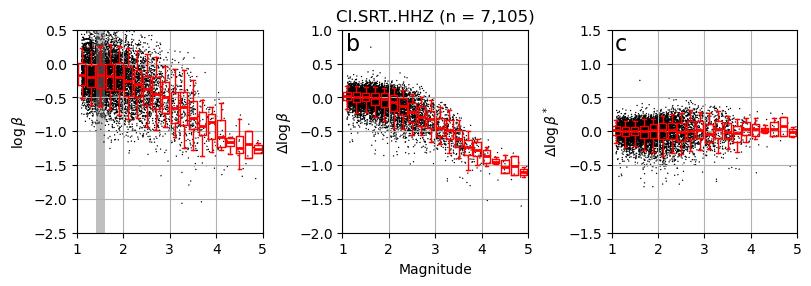

In [11]:
# Corrections for a single example station
from matplotlib.patches import Rectangle
import string

# for i, row in df_sta.iterrows():
#     print(i, row['station_name'], len(row['event_name']))

df_sta = p_results.metadata_st
df_calib = p_results.metadata_calib

stname = "CI.SRT..HHZ"
phase = "p"
# find index of the station of interest
stind_plot = df_sta[df_sta['station_name'] == stname].index[0]
df_plot = df_sta.iloc[stind_plot]

dx = 0.2
edges = np.arange(1.0, 7.3, dx)
ylim = np.array([-1.5, 1.5])

calib_mag_range = p_results.calib_mag_range

df_c = df_calib[df_calib['station_name']==stname]

fig, axs = plt.subplots(1,3, figsize=[8,2.75], sharex=True, sharey=False, layout='constrained')
# fig, axs = plt.subplots(1,3, figsize=[8,3], sharex=True, sharey=False, layout='constrained')
axs[0].scatter(df_plot['emag'], df_plot['logbeta'], c='k', s=1, edgecolors='none', label=r'$\log\beta$')
axs[0].scatter(df_c['emag'], df_c['logbeta'], c='k', s=1, edgecolors='none')

axs[1].scatter(df_plot['emag'], df_plot['dlogbeta'], c='k', s=1, edgecolors='none', label=r'$\Delta\log\beta$')
axs[2].scatter(df_plot['emag'], df_plot['dlogbeta_corr'], c='k', s=1, edgecolors='none', label=r'$\Delta\log\beta^*$')

boxplot(df_plot['emag'], df_plot['logbeta'], xbins=edges, ax=axs[0], color='r')
boxplot(df_c['emag'], df_c['logbeta'], xbins=edges, ax=axs[0], color='r')
boxplot(df_plot['emag'], df_plot['dlogbeta'], xbins=edges, ax=axs[1], color='r')
boxplot(df_plot['emag'], df_plot['dlogbeta_corr'], xbins=edges, ax=axs[2], color='r')

# shaded rectangle around calibration events range
axs[0].add_patch(Rectangle((calib_mag_range[0], -4.5), calib_mag_range[1]-calib_mag_range[0], 9, fill=True, facecolor='gray', alpha=0.5, edgecolor='none'))

axs[0].set_xlim([1.0, 5])
axs[0].set_ylim(ylim - 1)
axs[1].set_ylim(ylim - 0.5)
axs[2].set_ylim(ylim)
axs[1].set_xlabel('Magnitude')
axs[0].set_ylabel(r'$\log\beta$')
axs[1].set_ylabel(r'$\Delta\log\beta$')
axs[2].set_ylabel(r'$\Delta\log\beta^*$')
axs[1].set_title(f'{stname} (n = {len(df_plot['emag']):,.0f})')
# axs[0].legend()
# axs[1].legend()
# axs[2].legend()
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

# panel labels
for n, axes in enumerate(axs):
    axes.text(0.019, 0.90, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)
        
# plt.savefig(paper_figure_dir + f"p_corrections.pdf", bbox_inches='tight')
plt.show()

In [12]:
import utm

P = p_results.metadata_ev[p_results.ev_dep]
S = s_results.metadata_ev[s_results.ev_dep]

df = pd.merge(P, S, how='outer', on=['event_name', 'elat', 'elon', 'edep', 'emag', 'ex', 'ey'], suffixes=('_p', '_s'))


# read in past results
cnames = ["event_name", "eyr", "emon", "eday", "ehr", "emn", "esc", "emag", 
          "elat", "elon", "edep", "nst", "negf", "fc", "delsig"]

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds = pd.merge(ds_p, ds_s, how='outer', on='event_name', suffixes=('_p', '_s')) # tested, works
print(f"{len(ds):,} unique events with stress drop estimates from Vandevert et al. 2024")

df = pd.merge(df, ds, how='left', on='event_name')

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)

# This fixes a bug where df doesn't groupby correctly when delsig is np.nan
df.loc[np.isnan(df['delsig_p']), 'delsig_p'] = 0
df.loc[np.isnan(df['delsig_s']), 'delsig_s'] = 0
df.loc[np.isnan(df['fc_p']), 'fc_p'] = 0
df.loc[np.isnan(df['fc_s']), 'fc_s'] = 0

ds_p['ex'], ds_p['ey'], zn, zl = utm.from_latlon(
    ds_p['elat'].values, 
    ds_p['elon'].values
    )
ds_s['ex'], ds_s['ey'], zn, zl = utm.from_latlon(
    ds_s['elat'].values, 
    ds_s['elon'].values
    )

6,827 unique events with stress drop estimates from Vandevert et al. 2024


In [ ]:
# import matplotlib as mpl

# # filtering arrays 
# pp = np.ones(len(df), dtype=bool)
# pp[np.isnan(df['dlogbeta_p'])] = False  # remove nan values
# pp[df['dlogbeta_corr_p']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr
# ss = np.ones(len(df), dtype=bool)
# ss[np.isnan(df['dlogbeta_s'])] = False
# ss[df['dlogbeta_corr_s']==0.0] = False

# clim = [-0.333, 0.333]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.linspace(clim[0], clim[1], 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = df[pp]#[df['qmag']>2]
# dataname = 'dlogbeta_corr_p'
# datatitle = r"$\Delta\log\beta^*$"

# # cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

# # fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11.2, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})
# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0.05})


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# df_plot = df[ss]#[df['qmag']>2.5]
# dataname = 'dlogbeta_corr_s'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# cb_ax = fig.add_axes([0.905,.5,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)

# cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



# ### OLD DELSIG DATA

# clim = [1.5, 150]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = ds_p[~np.isnan(ds_p['delsig'])][ds_p['qmag']>2.0]
# dataname = 'delsig'
# datatitle = r"$\Delta\log\beta^*$"


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# df_plot = ds_s[~np.isnan(ds_s['delsig'])]
# df_plot = df_plot[df_plot['qmag']>2.5]
# dataname = 'delsig'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )



# cb_ax = fig.add_axes([0.905,.12,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)
# cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")

# for AX in ax.flatten():
#     AX.get_xaxis().set_ticks([])
#     AX.get_yaxis().set_ticks([])


# ax[0,0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[0,1].annotate(r"S-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,0].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,1].annotate(r"S-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)


# # panel labels
# for n, axes in enumerate(ax.flatten()):
#     axes.text(0.015, 0.95, string.ascii_lowercase[n], transform=axes.transAxes, 
#         size=20)


# # plt.savefig(f"{paper_figure_dir}map_comp.pdf", bbox_inches='tight')

# plt.show()

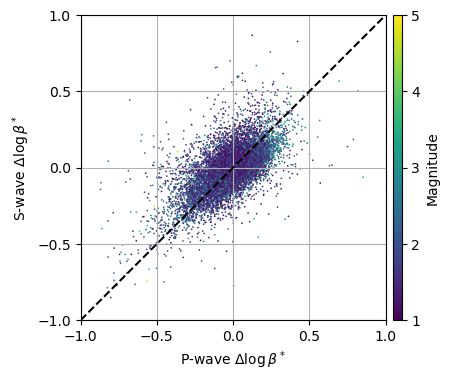

In [13]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
xlim = [-1, 1]


fig, ax = plt.subplots(1,1, figsize=(4,4), constrained_layout=True)
sc = ax.scatter(df['dlogbeta_corr_p'], df['dlogbeta_corr_s'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax.plot(xlim, xlim, c='k', linestyle='--')
ax.set_ylim(xlim)
ax.set_xlim(xlim)


ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
ax.set_ylabel(r"S-wave $\Delta\log\beta^*$")

ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True)
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)

cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# plt.savefig(f"{paper_figure_dir}PS_beta_comparison.pdf", bbox_inches='tight')

plt.show()

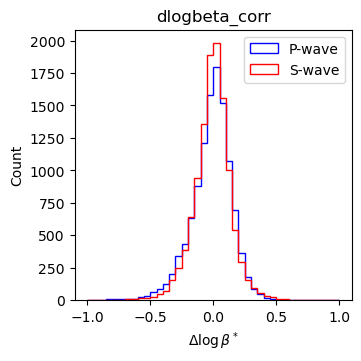

P-wave dlogbeta_corr
count    11429.000000
mean        -0.014736
std          0.160762
min         -0.961886
25%         -0.099713
50%          0.001662
75%          0.086907
max          0.852355
Name: dlogbeta_corr_p, dtype: float64
5% and 95% quantiles: 
 0.05   -0.299401
0.95    0.216743
Name: dlogbeta_corr_p, dtype: float64


S-wave dlogbeta_corr
count    11584.000000
mean        -0.007050
std          0.146149
min         -0.851950
25%         -0.084744
50%         -0.000241
75%          0.075911
max          0.868826
Name: dlogbeta_corr_s, dtype: float64
5% and 95% quantiles: 
 0.05   -0.252565
0.95    0.216490
Name: dlogbeta_corr_s, dtype: float64


In [14]:
# plot histogram of all dlogbeta_corr_p and dlogbeta_corr_s

fig, ax = plt.subplots(1,1, figsize=(3.5,3.5), constrained_layout=True)

ax.hist(df['dlogbeta_corr_p'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='P-wave', color='b')
ax.hist(df['dlogbeta_corr_s'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='S-wave', color='r')

ax.set_title(f'dlogbeta_corr')
ax.set_xlabel(r"$\Delta\log\beta^*$")
ax.set_ylabel('Count')
ax.legend()
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')

plt.show()

# print stats on each quantity (mean, median, std, min, max)
print("P-wave dlogbeta_corr")
print(df['dlogbeta_corr_p'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['dlogbeta_corr_p'].quantile([0.05, 0.95]))

print("\n\nS-wave dlogbeta_corr")
print(df['dlogbeta_corr_s'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['dlogbeta_corr_s'].quantile([0.05, 0.95]))

In [148]:
np.digitize(p_results.metadata_ev['emag'], edges)

array([17, 19, 20, ...,  4,  2,  3])

In [161]:
df

,event_name,nts_p,elat,elon,edep,emag,_eid_p,ex,ey,dlogbeta_p,dlogbeta_corr_p,nts_s,_eid_s,dlogbeta_s,dlogbeta_corr_s,delsig_p,fc_p,delsig_s,fc_s
0,37218988,113.0,35.688099,-117.505928,0.616,4.28,7063.0,454222.843094,3.949473e+06,-1.053250,-0.086931,162.0,7175.0,-0.968415,-0.111287,36.99,3.7,5.416,0.6
1,37219156,161.0,35.890999,-117.736504,9.100,4.64,8100.0,433528.878213,3.972109e+06,-1.214692,-0.140608,179.0,8233.0,-1.040212,-0.113918,0.00,0.0,27.610,1.1
2,37219164,160.0,35.795429,-117.615921,10.314,4.84,1961.0,444345.147865,3.961434e+06,-1.176816,-0.087703,202.0,1996.0,-1.198681,-0.258694,87.17,3.1,124.600,2.1
3,37219172,164.0,35.856430,-117.647141,12.833,4.61,1655.0,441568.837887,3.968218e+06,-1.365015,-0.296793,192.0,1685.0,-1.024104,-0.102639,0.00,0.0,77.530,2.0
4,37219180,182.0,35.919659,-117.720490,7.625,4.50,4455.0,434997.654873,3.975277e+06,-1.114956,-0.068227,186.0,4526.0,-1.016026,-0.112266,42.13,2.8,31.070,1.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11700,38592279,255.0,35.615219,-117.399620,5.555,1.55,1059.0,463808.951983,3.941345e+06,0.127987,0.132548,271.0,1081.0,0.245397,0.133287,1931.00,0.0,0.000,0.0
11701,38592287,255.0,35.788799,-117.606697,3.376,1.98,6150.0,445174.082273,3.960693e+06,0.058469,0.117080,269.0,6251.0,0.000000,-0.021137,31.57,37.2,11.650,16.7
11702,38592327,263.0,35.622261,-117.446167,4.234,1.75,3042.0,459597.007716,3.942145e+06,-0.041230,-0.020003,275.0,3094.0,0.107262,0.031151,38.17,46.1,0.000,0.0
11703,38592335,223.0,35.929470,-117.684570,1.965,1.22,8138.0,438245.952128,3.976342e+06,-0.113028,-0.119594,229.0,8273.0,0.105990,-0.047923,0.00,0.0,0.000,0.0


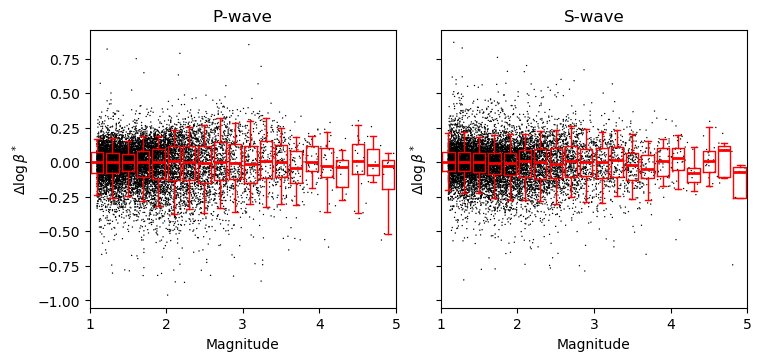

In [164]:
# plot dlogbeta_corr vs magnitude for P and S using boxplot

k1 = np.where(~np.isnan(df['dlogbeta_corr_p']))[0]
k2 = np.where(~np.isnan(df['dlogbeta_corr_s']))[0]



edges = np.arange(1.0, 7.3, 0.2)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)

ax1.scatter(df['emag'].values[k1], df['dlogbeta_corr_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['emag'].values[k2], df['dlogbeta_corr_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['emag'].values[k1], df['dlogbeta_corr_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['emag'].values[k2], df['dlogbeta_corr_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Magnitude')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.set_xlim([1, 5])
ax2.set_xlim([1, 5])

plt.show()

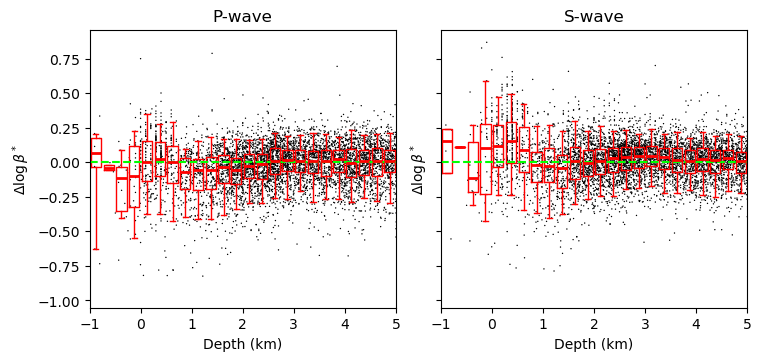

In [173]:
# plot dlogbeta_corr vs depth for P and S using boxplot

k1 = np.where(~np.isnan(df['dlogbeta_corr_p']))[0]
k2 = np.where(~np.isnan(df['dlogbeta_corr_s']))[0]



edges = np.arange(-1.0, 25, 0.25)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)




ax1.scatter(df['edep'].values[k1], df['dlogbeta_corr_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['edep'].values[k2], df['dlogbeta_corr_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['edep'].values[k1], df['dlogbeta_corr_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['edep'].values[k2], df['dlogbeta_corr_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Depth (km)')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Depth (km)')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.axhline(0, c='lime', ls='--')
ax2.axhline(0, c='lime', ls='--')



ax1.set_xlim([-1, 5])
ax2.set_xlim([-1, 5])

plt.show()

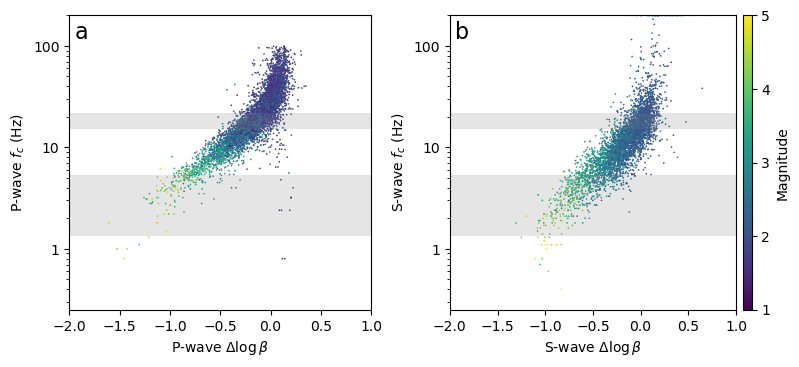

Mean, median magnitude of events with P-wave fc in high beta window: 2.07, 2.01
Mean, median magnitude of events with P-wave fc in low beta window: 3.70, 3.76
Mean, median magnitude of events with S-wave fc in high beta window: 2.23, 2.16
Mean, median magnitude of events with S-wave fc in low beta window: 3.25, 3.27


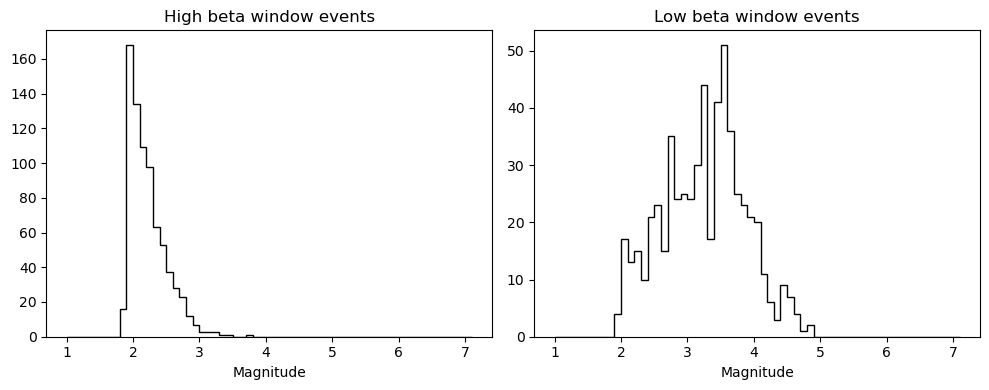

In [15]:
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

low_beta_window_p = p_results.low_window
low_beta_window_s = s_results.low_window

high_beta_window_p = p_results.high_window
high_beta_window_s = s_results.high_window

fcylim = [10**(-0.6), 200.0]
xlim = [-2, 1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7.5,3.5),
    layout='constrained')

# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

sc = ax[0].scatter(df['dlogbeta_p'], df['fc_p'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax[1].scatter(df['dlogbeta_s'], df['fc_s'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)

# grey rectangle for low_beta_window_p
ax[0].add_patch(Rectangle((xlim[0], low_beta_window_p[0]), xlim[1]-xlim[0], low_beta_window_p[1]-low_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[0].add_patch(Rectangle((xlim[0], high_beta_window_p[0]), xlim[1]-xlim[0], high_beta_window_p[1]-high_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))

ax[1].add_patch(Rectangle((xlim[0], low_beta_window_s[0]), xlim[1]-xlim[0], low_beta_window_s[1]-low_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[1].add_patch(Rectangle((xlim[0], high_beta_window_s[0]), xlim[1]-xlim[0], high_beta_window_s[1]-high_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))


ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(fcylim)
ax[1].set_ylim(fcylim)

ax[0].set_xlim(xlim)
ax[1].set_xlim(xlim)

ax[0].set_xlabel(r"P-wave $\Delta\log\beta$")
ax[1].set_xlabel(r"S-wave $\Delta\log\beta$")

ax[0].set_ylabel(r"P-wave $f_c$ (Hz)")
ax[1].set_ylabel(r"S-wave $f_c$ (Hz)")

ax[0].set_yticks([1, 10, 100])
ax[0].set_yticklabels([1, 10, 100])
ax[1].set_yticks([1, 10, 100])
ax[1].set_yticklabels([1, 10, 100])
# ax[0].set_yticks([0.3, 1, 3, 10, 30, 100])
# ax[0].set_yticklabels([0.3, 1, 3, 10, 30, 100])

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.019, 0.92, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)
        
# plt.savefig(f"{paper_figure_dir}PS_beta_fc_comparison.pdf", bbox_inches='tight')
plt.show()


###
mags_high_window = df['emag'][np.logical_and(df['fc_p']>=high_beta_window_p[0], df['fc_p']<=high_beta_window_p[1])]
mags_low_window = df['emag'][np.logical_and(df['fc_p']>=low_beta_window_p[0], df['fc_p']<=low_beta_window_p[1])]

print(f"Mean, median magnitude of events with P-wave fc in high beta window: {np.mean(mags_high_window):.2f}, {np.median(mags_high_window):.2f}")
print(f"Mean, median magnitude of events with P-wave fc in low beta window: {np.mean(mags_low_window):.2f}, {np.median(mags_low_window):.2f}")


# do the same for S-wave windows
mags_high_window = df['emag'][np.logical_and(df['fc_s']>=high_beta_window_s[0], df['fc_s']<=high_beta_window_s[1])]
mags_low_window = df['emag'][np.logical_and(df['fc_s']>=low_beta_window_s[0], df['fc_s']<=low_beta_window_s[1])]

print(f"Mean, median magnitude of events with S-wave fc in high beta window: {np.mean(mags_high_window):.2f}, {np.median(mags_high_window):.2f}")
print(f"Mean, median magnitude of events with S-wave fc in low beta window: {np.mean(mags_low_window):.2f}, {np.median(mags_low_window):.2f}")

# figure showing hists of mags_high_window and mags_low_window
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(mags_high_window, bins=np.arange(1.0, 7.2, 0.1), histtype='step', edgecolor='k')
ax[1].hist(mags_low_window, bins=np.arange(1.0, 7.2, 0.1), histtype='step', edgecolor='k')

ax[0].set_xlabel('Magnitude')
ax[1].set_xlabel('Magnitude')
ax[0].set_title('High beta window events')
ax[1].set_title('Low beta window events')

plt.tight_layout()
plt.show()

In [18]:
# find events within a fc range of the outer edges of the low and high beta windows
fc_low_range = [1, 2]
fc_high_range = [20, 24]

events_low_fc = df[np.logical_and(df['fc_p']>=fc_low_range[0], df['fc_p']<=fc_low_range[1])]
events_high_fc = df[np.logical_and(df['fc_p']>=fc_high_range[0], df['fc_p']<=fc_high_range[1])]

print(f"Mean, median magnitude of events with P-wave fc in low fc range: {np.mean(events_low_fc['emag']):.2f}, {np.median(events_low_fc['emag']):.2f}")
print(f"Mean, median magnitude of events with P-wave fc in high fc range: {np.mean(events_high_fc['emag']):.2f}, {np.median(events_high_fc['emag']):.2f}")


Mean, median magnitude of events with P-wave fc in low fc range: 5.10, 4.71
Mean, median magnitude of events with P-wave fc in high fc range: 1.97, 1.92


In [ ]:
# combined delsig vs dlogbeta* and fc vs dlogbeta


# dsylim = [1E-1, 1E4]
dsylim = [1E-1, 1E3]
xlim = [-1, 1]

vmin, vmax = 1, 5.0

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(5.75,4.75),
    layout='constrained')

# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

keep = df['emag'] >= 1.0
sc = ax[0,0].scatter(df['dlogbeta_corr_p'][keep], df['delsig_p'][keep], c=df['emag'][keep], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax[0,1].scatter(df['dlogbeta_corr_s'][keep], df['delsig_s'][keep], c=df['emag'][keep], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)




ax[0,0].set_yscale('log')
ax[0,1].set_yscale('log')
ax[0,0].set_ylim(dsylim)
ax[0,1].set_ylim(dsylim)

ax[0,0].set_xlim(xlim)
ax[0,1].set_xlim(xlim)

ax[0,0].set_xticks([-1, 0, 1])
ax[0,1].set_xticks([-1, 0, 1])
ax[0,0].set_xticklabels([-1, 0, 1])
ax[0,1].set_xticklabels([-1, 0, 1])

# ax[0,0].set_xlabel(r"P-wave $\Delta\log\beta^*$")
# ax[0,1].set_xlabel(r"S-wave $\Delta\log\beta^*$")
# ax[0,0].set_ylabel(r"P-wave $\Delta\sigma$ (MPa)")
# ax[0,1].set_ylabel(r"S-wave $\Delta\sigma$ (MPa)")

ax[0,0].set_xlabel(r"$\Delta\log\beta^*$", labelpad=-4)
ax[0,1].set_xlabel(r"$\Delta\log\beta^*$", labelpad=-4)
ax[0,0].set_ylabel(r"$\Delta\sigma$ (MPa)", labelpad=-6)
ax[0,1].set_ylabel(r"$\Delta\sigma$ (MPa)", labelpad=-6)

# ax[0,0].set_yticks([0.1, 1, 10, 100, 1000, 10000])
# ax[0,1].set_yticks([0.1, 1, 10, 100, 1000, 10000])
# ax[0,0].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])
# ax[0,1].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])

ax[0,0].set_yticks([0.1, 1, 10, 100, 1000])
ax[0,1].set_yticks([0.1, 1, 10, 100, 1000])
ax[0,0].set_yticklabels([0.1, 1, 10, 100, 1000])
ax[0,1].set_yticklabels([0.1, 1, 10, 100, 1000])


ax[0,0].set_title('P-wave')
ax[0,1].set_title('S-wave')




low_beta_window_p = p_results.low_window
low_beta_window_s = s_results.low_window

high_beta_window_p = p_results.high_window
high_beta_window_s = s_results.high_window

fcylim = [10**(-0.6), 200.0]
xlim = [-2, 1]



# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

sc = ax[1,0].scatter(df['dlogbeta_p'], df['fc_p'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=vmin, vmax=vmax)
ax[1,1].scatter(df['dlogbeta_s'], df['fc_s'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=vmin, vmax=vmax)

# grey rectangle for low_beta_window_p
ax[1,0].add_patch(Rectangle((xlim[0], low_beta_window_p[0]), xlim[1]-xlim[0], low_beta_window_p[1]-low_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[1,0].add_patch(Rectangle((xlim[0], high_beta_window_p[0]), xlim[1]-xlim[0], high_beta_window_p[1]-high_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))

ax[1,1].add_patch(Rectangle((xlim[0], low_beta_window_s[0]), xlim[1]-xlim[0], low_beta_window_s[1]-low_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[1,1].add_patch(Rectangle((xlim[0], high_beta_window_s[0]), xlim[1]-xlim[0], high_beta_window_s[1]-high_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))


ax[1,0].set_yscale('log')
ax[1,1].set_yscale('log')
ax[1,0].set_ylim(fcylim)
ax[1,1].set_ylim(fcylim)

ax[1,0].set_xlim(xlim)
ax[1,1].set_xlim(xlim)

# ax[1,0].set_xlabel(r"P-wave $\Delta\log\beta$")
# ax[1,1].set_xlabel(r"S-wave $\Delta\log\beta$")
# ax[1,0].set_ylabel(r"P-wave $f_c$ (Hz)")
# ax[1,1].set_ylabel(r"S-wave $f_c$ (Hz)")

ax[1,0].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[1,1].set_xlabel(r"$\Delta\log\beta$", labelpad=-4)
ax[1,0].set_ylabel(r"$f_c$ (Hz)", labelpad=-6)
ax[1,1].set_ylabel(r"$f_c$ (Hz)", labelpad=-6)

ax[1,0].set_yticks([1, 10, 100])
ax[1,0].set_yticklabels([1, 10, 100])
ax[1,1].set_yticks([1, 10, 100])
ax[1,1].set_yticklabels([1, 10, 100])
# ax[1,0].set_yticks([0.3, 1, 3, 10, 30, 100])
# ax[1,0].set_yticklabels([0.3, 1, 3, 10, 30, 100])

# divider = make_axes_locatable(ax[1,1])
# cax = divider.append_axes("right", size="3%", pad=.07)

# plt.colorbar(sc, cax=cax)
# cax.set_ylabel('Magnitude')
# cax.set_yticks([1, 2, 3, 4, 5])

# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.90, 0.885, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)

# divider = make_axes_locatable(ax[:,1])
# cax = divider.append_axes("right", size="3%", pad=.07)

# plt.colorbar(sc, cax=cax)
# cax.set_ylabel('Magnitude')
# cax.set_yticks([1, 2, 3, 4, 5])

cbar = fig.colorbar(sc, ax=ax[:,1], pad=0.03, label='Magnitude', aspect=50)
cax = cbar.ax
cax.set_yticks([1, 2, 3, 4, 5])
        
# plt.savefig(f"{paper_figure_dir}PS_delsig_fc_combined.pdf", bbox_inches='tight')
plt.show()

outlier_p = df[df['delsig_p']>1000]
outlier_s = df[df['delsig_s']>1000]

# plot histogram of outliers on one axis
fig, ax = plt.subplots(1,1, figsize=(4,4), constrained_layout=True)
ax.hist(outlier_p['emag'], bins=np.arange(1.0, 7.2, 0.1), histtype='step', label='P-wave', color='b')
ax.hist(outlier_s['emag'], bins=np.arange(1.0, 7.2, 0.1), histtype='step', label='S-wave', color='r')
ax.set_title(f'Outlier Events (delsig > 1000)')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count')
ax.legend()
plt.show()

print("P-wave outliers:", len(outlier_p))
print("S-wave outliers:", len(outlier_s))

In [ ]:
# import mapping_tools as mt
# from obspy.imaging.beachball import beach
# from copy import copy

# # 38443183  6.40 -117.50382995605  35.70532989502  10.500  -1.15562105718   0.00000000000
# # 38457511  7.10 -117.59932708740  35.76950073242   8.000  -1.25005195530   0.00000000000

# moment_tensors = np.array([[-0.455, -5.680, 6.130, -0.004, -0.564, 0.487],
#                            [-0.233, -4.110, 4.340, 0.508, 0.492, 0.948]])

# mt_width = 3000


# lx, ly, zn, zl = utm.from_latlon(
#     np.array([35.70532989502, 35.76950073242]),
#     np.array([-117.50382995605, -117.59932708740])
# )

# mt71 = [160, 84, -165]
# mt64 = [139, 85, -178]


# # m64 = beach(moment_tensors[0], xy=(lx[0], ly[0]), facecolor='k', linewidth=0.6, width=mt_width/1.3)
# # m71 = beach(moment_tensors[1], xy=(lx[1], ly[1]), facecolor='k', linewidth=0.6, width=mt_width)

# m64 = beach(mt64, xy=(lx[0], ly[0]), facecolor='k', linewidth=0.6, width=mt_width/1.3)
# m71 = beach(mt71, xy=(lx[1], ly[1]), facecolor='k', linewidth=0.6, width=mt_width)
# # filtering arrays 
# pp = np.ones(len(df), dtype=bool)
# pp[np.isnan(df['dlogbeta_p'])] = False  # remove nan values
# pp[df['dlogbeta_corr_p']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr
# ss = np.ones(len(df), dtype=bool)
# ss[np.isnan(df['dlogbeta_s'])] = False
# ss[df['dlogbeta_corr_s']==0.0] = False

# clim = [-0.333, 0.333]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.linspace(clim[0], clim[1], 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = df[pp]
# df_plot = df_plot[df_plot['emag']>2]
# dataname = 'dlogbeta_corr_p'
# datatitle = r"$\Delta\log\beta^*$"

# # cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12.3, 14.6), sharex=True, sharey=True, gridspec_kw={'wspace':0.03, 'hspace':0.03})
# # fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0.05})


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),
#     zname='edep',
#     markersizing='emag',
#     xname='ex',
#     yname='ey'
# )


# df_plot = df[ss]
# df_plot = df_plot[df_plot['emag']>2.5]

# dataname = 'dlogbeta_corr_s'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),
#     zname='edep',
#     markersizing='emag',
#     xname='ex',
#     yname='ey'
# )

# # cb_ax = fig.add_axes([0.905,.5,.015,.37])
# # cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
# #     cax=cb_ax, extend='neither')

# cbar = fig.colorbar(smap, ax=ax[0,:], pad=0.01, label=r"$\Delta\log\beta^*$", aspect=50)
# cb_ax = cbar.ax

# smap.set_clim(clim)

# # cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



# ### OLD DELSIG DATA

# clim = [1.5, 150]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = ds_p[~np.isnan(ds_p['delsig'])][ds_p['emag']>2.0]
# dataname = 'delsig'
# datatitle = r"$\Delta\log\beta^*$"


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),
#     zname='edep',
#     markersizing='emag',
#     xname='ex',
#     yname='ey'
# )

# df_plot = ds_s[~np.isnan(ds_s['delsig'])]
# df_plot = df_plot[df_plot['emag']>2.5]
# dataname = 'delsig'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),
#     zname='edep',
#     markersizing='emag',
#     xname='ex',
#     yname='ey'
# )



# # cb_ax = fig.add_axes([0.905,.12,.015,.37])
# # cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
# #     cax=cb_ax, extend='neither')
# cbar = fig.colorbar(smap, ax=ax[1,:], pad=0.01, label=r"$\Delta \sigma$ (MPa)", aspect=50)
# cb_ax = cbar.ax

# smap.set_clim(clim)
# # cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")




# for AX in ax.flatten():
#     AX.get_xaxis().set_ticks([])
#     AX.get_yaxis().set_ticks([])


# ax[0,0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[0,1].annotate(r"S-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,0].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,1].annotate(r"S-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)


# # beachballs

# an_x, an_y = (458000, 442000), (3955000, 3955000)


# for AX in ax.flatten():
#     AX.add_collection(copy(m64))
#     AX.add_collection(copy(m71))
#     AX.annotate('M6.4', xy=(an_x[0], an_y[0]), color='k', fontsize=14, ha='left', va='bottom')
#     AX.annotate('M7.1', xy=(an_x[1], an_y[1]), color='k', fontsize=14, ha='right', va='top')
#     # beachball coordinates are at lx, ly. draw line between first beachball and first annotation
#     AX.plot([lx[0], an_x[0]], [ly[0], an_y[0]], c='k', lw=1)
#     AX.plot([lx[1], an_x[1]], [ly[1], an_y[1]], c='k', lw=1)


# # add scalebars
# xrange = ax[0,0].get_xlim()
# yrange = ax[0,0].get_ylim()

# sbar_len = 10000

# sbar_x = np.array([np.mean(xrange)-sbar_len/2, np.mean(xrange)+sbar_len/2])
# sbar_y = np.array([(yrange[1]-yrange[0])*.98 + yrange[0], (yrange[1]-yrange[0])*.98 + yrange[0]])

# for AX in ax.flatten():
#     AX.plot(sbar_x, sbar_y, c='k', lw=2)
#     AX.text(np.mean(sbar_x), np.mean(sbar_y)-500, "10 km", fontsize=14, ha='center', va='top')
#     # put ticks on both ends of the scalebar
#     AX.plot([sbar_x[0], sbar_x[0]], sbar_y+np.array([-500, 500]), c='k', lw=2)
#     AX.plot([sbar_x[1], sbar_x[1]], sbar_y+np.array([-500, 500]), c='k', lw=2)


# # panel labels
# for n, axes in enumerate(ax.flatten()):
#     axes.text(0.015, 0.95, string.ascii_lowercase[n], transform=axes.transAxes, 
#         size=20)


# plt.savefig(f"{paper_figure_dir}map_comp.pdf", bbox_inches='tight')

# plt.show()

# $\Kappa_0$ analysis

Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,684
Stations: 169
Records:  313,783

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.40 to 1.60
Calibration events:  1,724 (13.59%)
Calibration records: 33,744 (10.75%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.

KAPPA0 ESTIMATION
----------------------------
20082 of 33684 records removed for being too far away.
29 of 77 stations removed for having a distance 

100%|██████████| 101/101 [00:00<00:00, 163.96it/s]


Best-fit slope: -0.012168
logbeta_brune =  [-0.13679788]
group_stations()
   _sid    kappa0
0   101 -0.032874
1    44 -0.021300
2    58 -0.012620
3    45 -0.027931
4     2 -0.032575
..  ...       ...
87   76 -0.027970
88  128 -0.020405
89   41 -0.007321
90   42 -0.008448
91   77 -0.006461

[92 rows x 2 columns]


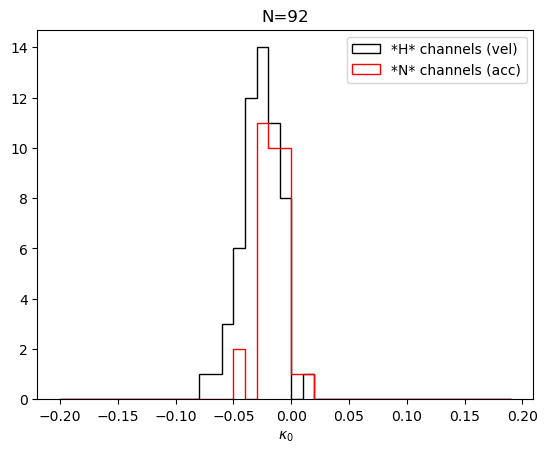

In [ ]:
importlib.reload(beta_compute)
from beta_compute import BetaEstimator
p_results = BetaEstimator(metadata_df=df_p, spectra=p_spectra, f=f, save_dir=p_results_dir)
p_results = p_results.compute(recompute=False)
p_results = p_results.estimate_kappa0(fc_fixed=30, d_nearby=20, range_min=15, n_min=50)

res = p_results.metadata_st[['station_name', 'kappa0', 'slat', 'slon']].copy()
res['units'] = res['station_name'].str[-2]

# drop rows with kappa0=NaN
res = res.dropna(subset=['kappa0']).reset_index(drop=True)

edges = np.arange(-0.2, 0.2, 0.01)
midpoints = (edges[:-1] + edges[1:])/2

plt.figure()
plt.hist(res['kappa0'][res['units'] == 'H'], color='k', bins=edges, histtype='step', label='*H* channels (vel)')
plt.hist(res['kappa0'][res['units'] == 'N'], color='r', bins=edges, histtype='step', label='*N* channels (acc)')
plt.xlabel(r"$\kappa_0$")
plt.title(f"N={len(res)}")
plt.legend()
plt.show()

In [ ]:
# n=0
# for i, row in p_results.metadata_st.iterrows():

#     if len(row['event_name']) >= 50 and n < 5:
#         plt.figure()
#         sc = plt.scatter(row['emag'], row['logbeta'], c=np.log10(row['stn']), cmap='PuBu', marker='.', s=1, vmin=0)
#         cbar = plt.colorbar(sc)
#         cbar.set_label("log(STN)")
#         plt.xlabel("Magnitude")
#         plt.ylabel(r"$\log\beta$")
#         plt.title(row['station_name'])
#         plt.show()

#         n += 1


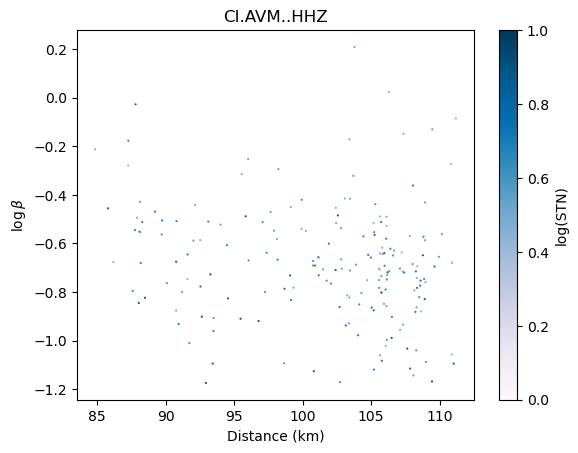

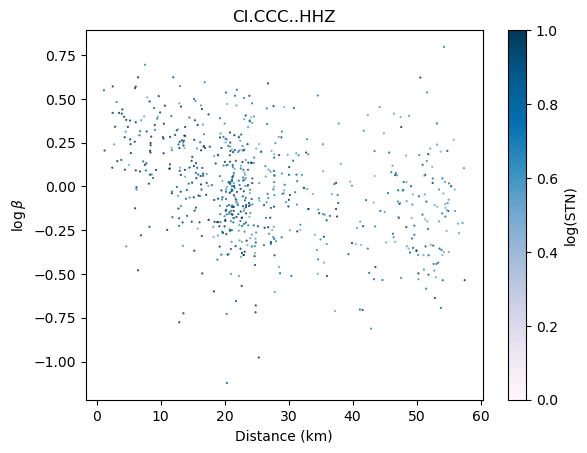

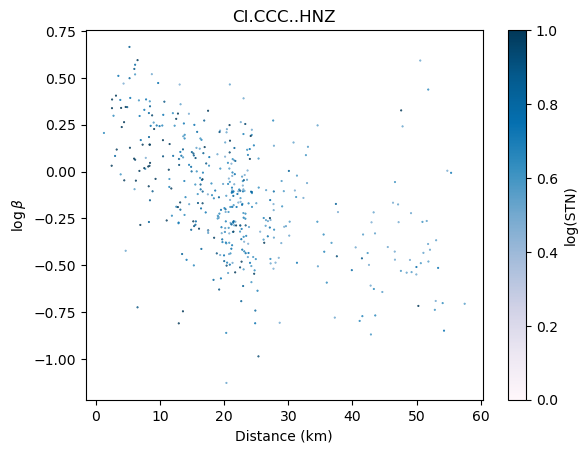

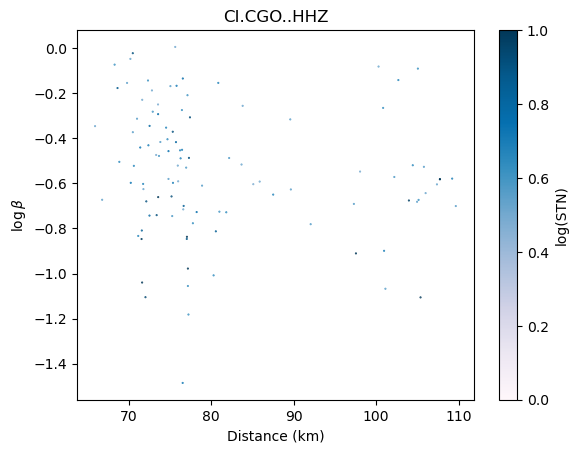

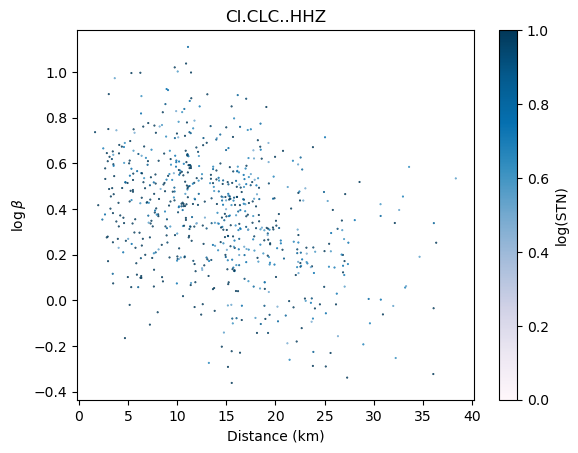

In [ ]:
n=0
for i, row in p_results.df_sta_calib.iterrows():

    if len(row['event_name']) >= 50 and n < 5:
        plt.figure()
        sc = plt.scatter(row['deldist'], row['logbeta'], c=np.log10(row['stn']), cmap='PuBu', marker='.', s=1, vmin=0, vmax=1)
        cbar = plt.colorbar(sc)
        cbar.set_label("log(STN)")
        plt.xlabel("Distance (km)")
        plt.ylabel(r"$\log\beta$")
        plt.title(row['station_name'])
        plt.show()

        n += 1

Box width: 36.99 km


/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_33749/1695109281.py:17: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker (6).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(res['slon'][res['units'] == 'H'], res['slat'][res['units'] == 'H'], c=res['kappa0'][res['units'] == 'H'], cmap=cmap, marker=6, s=80, norm=cnorm, edgecolors='k', label='*H* channels (vel)')
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_33749/1695109281.py:18: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker (7).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(res['slon'][res['units'] == 'N'], res['slat'][res['units'] == 'N'], c=res['kappa0'][res['units'] == 'N'], cmap=cmap, marker=7, s=80, norm=cnorm, edgecolors='k', label='*N* channels (acc)')


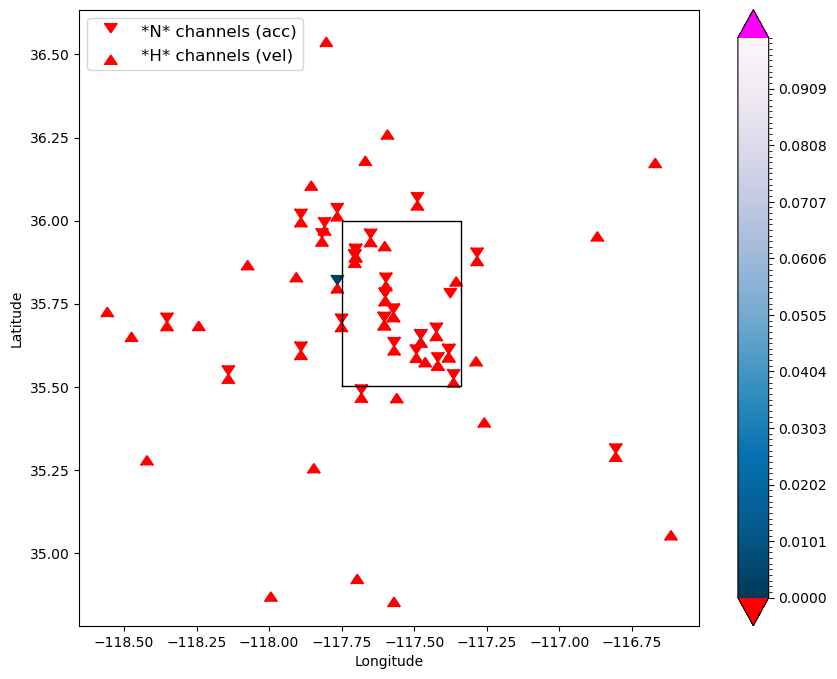

In [84]:
elat_range = [p_results.metadata_df['elat'].min(), p_results.metadata_df['elat'].max()]
elon_range = [p_results.metadata_df['elon'].min(), p_results.metadata_df['elon'].max()]

# how wide is the area
box_width = (p_results.metadata_df['ex'].max() - p_results.metadata_df['ex'].min())/1000
print(f"Box width: {box_width:.2f} km")

cmap = mpl.cm.PuBu.reversed()
cmap.set_extremes(under='r', over='magenta')
bounds = np.linspace(0, 0.1, 100)
cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')
smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)



plt.figure(figsize=(10,8))
plt.scatter(res['slon'][res['units'] == 'H'], res['slat'][res['units'] == 'H'], c=res['kappa0'][res['units'] == 'H'], cmap=cmap, marker=6, s=80, norm=cnorm, edgecolors='k', label='*H* channels (vel)')
plt.scatter(res['slon'][res['units'] == 'N'], res['slat'][res['units'] == 'N'], c=res['kappa0'][res['units'] == 'N'], cmap=cmap, marker=7, s=80, norm=cnorm, edgecolors='k', label='*N* channels (acc)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(0,1), fontsize=12)

# plot box around elat_range and elon_range
plt.plot([elon_range[0], elon_range[0], elon_range[1], elon_range[1], elon_range[0]], 
         [elat_range[0], elat_range[1], elat_range[1], elat_range[0], elat_range[0]], c='k', lw=1)

plt.colorbar()


plt.show()

In [ ]:
# find _sid of CI.CLC.HHZ

p_results.metadata_st[p_results.metadata_st['station_name'] == 'ZY.SV01..HNZ']

In [49]:
len(p_results.df_sta_calib['event_name'].values[0])

603

In [58]:
test = p_results.df_sta_calib[p_results.df_sta_calib['deldist'].apply(max) - p_results.df_sta_calib['deldist'].apply(min) > 50]
test

for i, row in p_results.df_sta_calib.iterrows():
    # print station name and range of deldist (max - min) for each station
    print(row['station_name'], "\t\t", np.array(row['deldist']).max() - np.array(row['deldist']).min(), "\t", np.array(row['deldist']).max(), "\t", np.array(row['deldist']).min(), "\t", np.array(row['deldist']).shape)

CI.CCC..HHZ 		 48.805025815963745 	 49.965633392333984 	 1.1606075763702393 	 (603,)
CI.CCC..HNZ 		 48.70447659492493 	 49.965633392333984 	 1.2611567974090576 	 (418,)
CI.CLC..HHZ 		 36.72875225543976 	 38.360023498535156 	 1.631271243095398 	 (673,)
CI.CLC..HNZ 		 30.195871233940125 	 32.15113830566406 	 1.955267071723938 	 (124,)
CI.JRC2..HHZ 		 42.4218692779541 	 49.96912384033203 	 7.54725456237793 	 (713,)
CI.JRC2..HNZ 		 42.01778984069824 	 49.56504440307617 	 7.54725456237793 	 (282,)
CI.LRL..HHZ 		 39.80041313171387 	 49.80905532836914 	 10.008642196655273 	 (672,)
CI.LRL..HNZ 		 37.62946891784668 	 48.94519805908203 	 11.315729141235352 	 (156,)
CI.MPM..HHZ 		 42.54254674911499 	 49.94170379638672 	 7.3991570472717285 	 (907,)
CI.MPM..HNZ 		 36.180638790130615 	 43.579795837402344 	 7.3991570472717285 	 (54,)
CI.SLA..HHZ 		 40.40059947967529 	 49.48123550415039 	 9.080636024475098 	 (599,)
CI.SLA..HNZ 		 35.20989513397217 	 44.290531158447266 	 9.080636024475098 	 (236,)
CI.S

In [13]:
def compute_logbeta(spectrum, low_f_ind, high_f_ind):
    # spectrum is an (nf) array
    low_band = np.median(np.log10(spectrum[low_f_ind[0]:low_f_ind[1]+1]))
    high_band = np.median(np.log10(spectrum[high_f_ind[0]:high_f_ind[1]+1]))
    logbeta = high_band - low_band
    return logbeta

corr = (2*np.pi*f)**-1

corr_logbeta = compute_logbeta(corr, p_results.low_window_inds, p_results.high_window_inds)
print(corr_logbeta)

-0.7481880270062005


/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_33749/4106475412.py:8: RuntimeWarning: divide by zero encountered in reciprocal
  corr = (2*np.pi*f)**-1


/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/obspy/core/inventory/response.py:2318: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower center", ncol=3, fontsize='small')


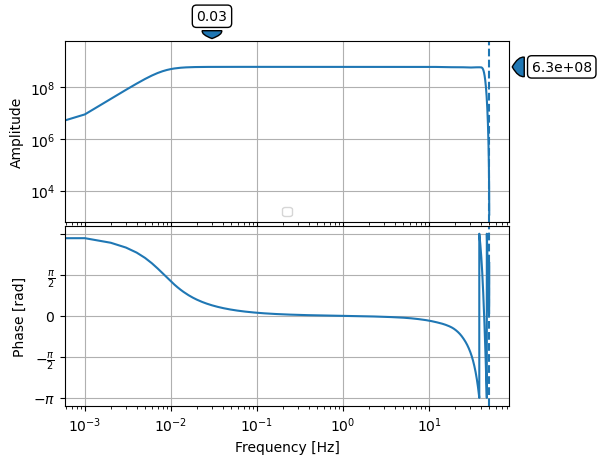

/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/obspy/core/inventory/response.py:2318: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower center", ncol=3, fontsize='small')


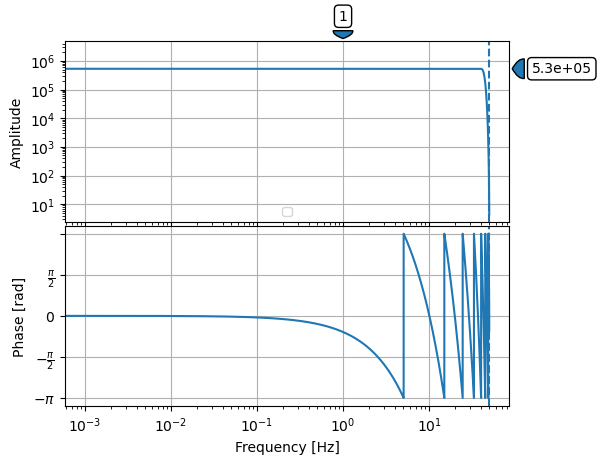

In [11]:
# import read_inventory from obspy
from obspy import read_inventory

inv1 = read_inventory("data/CI.CCC..HHZ_inv.xml")
inv2 = read_inventory("data/CI.CCC..HNZ_inv.xml")

resp1 = inv1[0][0][0].response
resp2 = inv2[0][0][0].response

resp1.plot(min_freq=0.001, output='VEL')
resp2.plot(min_freq=0.001, output='ACC')
plt.show()

/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_33749/2304273088.py:24: RuntimeWarning: invalid value encountered in divide
  plt.plot(f1, np.abs(r1) / np.abs(r2), c='b')


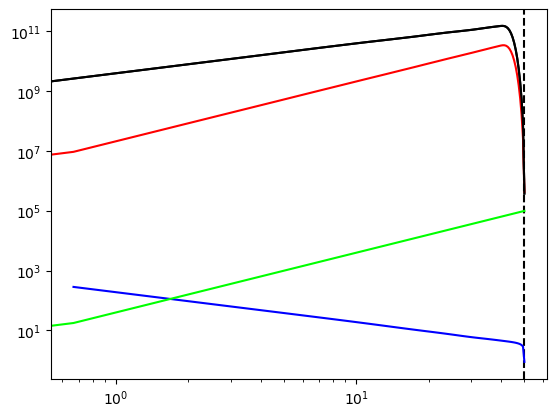

In [14]:
sampling_rate = 100.0
min_freq = 2.0/3.0

t_samp = 1.0 / sampling_rate
nyquist = sampling_rate / 2.0
nfft = int(sampling_rate / min_freq)
output1="DISP"
output2="DISP"


r1, f1 = resp1.get_evalresp_response(
            t_samp=0.01, nfft=nfft, output=output1, start_stage=None,
            end_stage=None)

r2, f2 = resp2.get_evalresp_response(
            t_samp=0.01, nfft=nfft, output=output2, start_stage=None,
            end_stage=None)

plt.figure()
plt.loglog(f1, np.abs(r1), c='k')
plt.loglog(f2, np.abs(r2), c='r')
plt.axvline(50, c='k', ls='--')
plt.loglog(f1, np.abs(r1), c='k')
plt.plot(f1, np.abs(r1) / np.abs(r2), c='b')
plt.plot(f1, (2*np.pi*f1)**2, c='lime')
plt.show()

lb1 = compute_logbeta(np.abs(r1), p_results.low_window_inds, p_results.high_window_inds)


In [ ]:
nfft

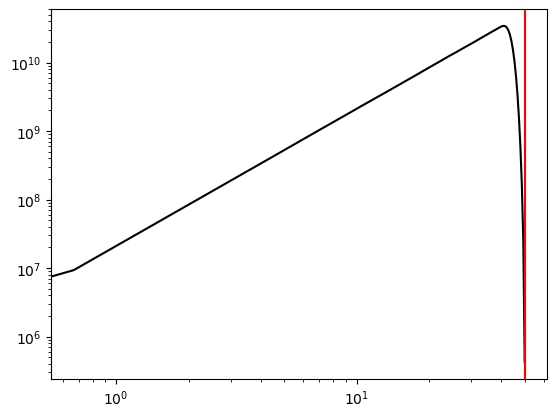

lb1-lb2:  -0.7635685335113234


In [15]:

output2="DISP"

r2, f2 = resp2.get_evalresp_response(
            t_samp=0.01, nfft=nfft, output=output2, start_stage=None,
            end_stage=None)

plt.figure()
plt.loglog(f2, np.abs(r2), c='k')
plt.axvline(50, c='r')
plt.show()

lb2 = compute_logbeta(np.abs(r2), p_results.low_window_inds, p_results.high_window_inds)

print('lb1-lb2: ', lb1-lb2)

In [ ]:
# # hist of results.kappa0

# plt.figure()
# plt.hist(results.kappa0, bins=25)
# plt.xlabel(r"$\kappa_0$")
# plt.ylabel('Count')
# plt.show()

In [ ]:
full_df_s = pd.read_pickle("/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/s_spectra.pkl")

spectra_s = full_df_s[['s2']].values
spectra_s = np.stack(spectra_s.flatten()).astype(float)


results_s = BetaEstimator(metadata_df=full_df_s, spectra=spectra_s, f=f)
results_s.compute()


In [106]:
plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['logbeta'], s=1, c='k', edgecolors='none')
plt.ylim([-3,3])
plt.show()

plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['dlogbeta'], s=1, c='k', edgecolors='none')
plt.plot(results_s.correction_mags, results_s.correction_function, c='r', marker='o')
plt.ylim([-3,3])
plt.show()

plt.figure()
plt.scatter(results_s.metadata_df['emag'], results_s.metadata_df['dlogbeta_corr'], s=1, c='k', edgecolors='none')
plt.ylim([-3,3])
plt.show()

NameError: name 'results_s' is not defined

<Figure size 640x480 with 0 Axes>

/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


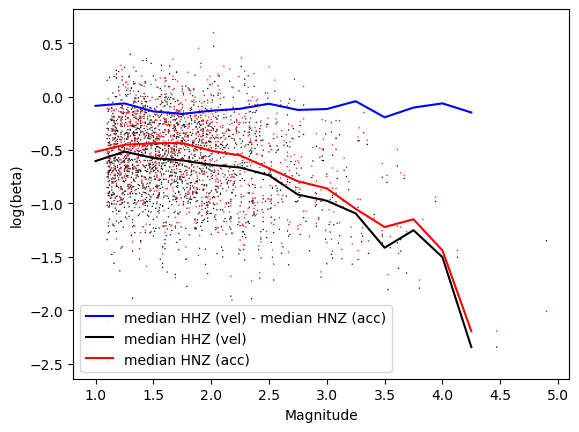

-0.10794291211065331 0.7799326257129232


In [107]:
# sids = [44, 58] # CI.CCC

# sids = [2, 13] # CI.CLC

sids = [11, 39] # ZY.SV01

# index 0 is CI.CCC..HHZ (vel)
# index 1 is CI.CCC..HNZ (acc)

rows = p_results.metadata_st[p_results.metadata_st['_sid'].isin(sids)].reset_index(drop=True)

x1 = np.array(rows.at[0, 'emag'])
x2 = np.array(rows.at[1, 'emag'])
y1 = np.array(rows.at[0, 'logbeta'])
y2 = np.array(rows.at[1, 'logbeta'])

xbin = np.arange(1.0, 7.3, 0.25)

# bin x arrays based on xbin
x1_binned = np.digitize(x1, xbin)-1
x2_binned = np.digitize(x2, xbin)-1

# compute median y for each bin
y1_median = np.zeros(len(xbin))
y2_median = np.zeros(len(xbin))
for i in range(len(xbin)):
    y1_median[i] = np.median(y1[x1_binned == i])
    y2_median[i] = np.median(y2[x2_binned == i])




plt.figure()
plt.scatter(rows.at[0, 'emag'], rows.at[0, 'logbeta'], s=1, c='k', edgecolors='none')
plt.scatter(rows.at[1, 'emag'], rows.at[1, 'logbeta'], s=1, c='r', edgecolors='none')
plt.plot(xbin, y1_median - y2_median, 'b', label='median HHZ (vel) - median HNZ (acc)')
plt.plot(xbin, y1_median, 'k', label='median HHZ (vel)')
plt.plot(xbin, y2_median, 'r', label='median HNZ (acc)')
plt.xlabel('Magnitude')
plt.ylabel('log(beta)')
plt.legend(loc='lower left')
plt.show()

meandif = np.nanmean((y1_median - y2_median)[np.where(xbin <= 4)])
print(meandif, 10**meandif)

In [ ]:

# dsylim = [1E-1, 1E4]
# xlim = [-1, 1]

# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7.5,3.5),
#     layout='constrained')

# # ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# # ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

# keep = df['emag'] >= 1.0
# sc = ax[0].scatter(df['dlogbeta_corr_p'][keep], df['delsig_p'][keep], c=df['emag'][keep], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
# ax[1].scatter(df['dlogbeta_corr_s'][keep], df['delsig_s'][keep], c=df['emag'][keep], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)




# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# ax[0].set_ylim(dsylim)
# ax[1].set_ylim(dsylim)

# ax[0].set_xlim(xlim)
# ax[1].set_xlim(xlim)

# ax[0].set_xlabel(r"P-wave $\Delta\log\beta^*$")
# ax[1].set_xlabel(r"S-wave $\Delta\log\beta^*$")

# ax[0].set_ylabel(r"P-wave $\Delta\sigma$ (MPa)")
# ax[1].set_ylabel(r"S-wave $\Delta\sigma$ (MPa)")

# ax[0].set_yticks([0.1, 1, 10, 100, 1000, 10000])
# ax[1].set_yticks([0.1, 1, 10, 100, 1000, 10000])
# ax[0].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])
# ax[1].set_yticklabels([0.1, 1, 10, 100, 1000, 10000])

# divider = make_axes_locatable(ax[1])
# cax = divider.append_axes("right", size="3%", pad=.07)

# plt.colorbar(sc, cax=cax)
# cax.set_ylabel('Magnitude')
# cax.set_yticks([1, 2, 3, 4, 5])

# # panel labels
# for n, axes in enumerate(ax.flatten()):
#     axes.text(0.019, 0.92, string.ascii_lowercase[n], transform=axes.transAxes, 
#         size=16)

# plt.savefig(f"{paper_figure_dir}PS_beta_delsig_comparison.pdf", bbox_inches='tight')
# plt.show()


In [ ]:
print(np.max(results.metadata_df['ex']) - np.min(results.metadata_df['ex']))
print(np.max(results.metadata_df['ey']) - np.min(results.metadata_df['ey']))

In [ ]:
np.sum(np.isnan(results.metadata_df['dlogbeta']))

In [ ]:
# importlib.reload(beta_compute)
# from beta_compute import BetaEstimator

test_df = metadata_df.copy()

test_df = beta_compute._get_id_from_column(test_df, 'event_id', 'eid')
test_df = beta_compute._get_id_from_column(test_df, 'stid', 'sid')
# test_df[test_df['sid']==7]

In [ ]:
# brune = 1 / (1 + (f_corr / 30)**2)
# brune_acc = brune * (2*np.pi*f_corr)**2

# brune_corr = brune_acc * (2*f_corr*np.pi)**-2

# plt.figure()
# plt.plot(f_corr, corr[:10, :].T, c='b', lw=2)
# plt.plot(f_corr, brune, c='k', lw=2, label='disp brune')
# plt.plot(f_corr, brune_acc, c='r', lw=2, label='acc brune')
# plt.plot(f_corr, brune_corr, 'r--', lw=2, label='corrected brune')
# # plt.plot(f_corr, (2*f_corr*np.pi)**-1, c='lime', ls=':', label='velocity correction')
# plt.plot(f_corr, (2*f_corr*np.pi)**-2, c='lime', ls=':', label='acc correction')




# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Correction')
# plt.legend()
# plt.xscale('log')
# plt.yscale('log')
# plt.show()

In [ ]:
# # toy problem:
# # assume all calib_sid are in target_sid and all target_sid are in calib_sid
# target_sid = np.array([0, 1, 4, 7, 9]) # these should be unique (1 event, many stations)
# calib_sid = np.array([4, 4, 7, 0, 1, 4, 9, 9]) # these are not necessarily unique (many events, many stations)

# target_logbeta = np.array([0.5, 0.1, -1.0, -2.4, 0.8])
# calib_logbeta = np.array([5, 6, 7, 8, 9, 10, 11, 12])

# # indices of target_sid in calib_sid
# v = np.searchsorted(target_sid, calib_sid)
# print('v:', v)
# print('calib_logbeta:', calib_logbeta[v])

# print('target_sid[v]:', target_sid[v])
# print('target_logbeta[v]:', target_logbeta[v])

# print('want -1, -1, -2.4, 0.5, 0.1, -1, 0.8, 0.8')


In [ ]:
# # synthetic test: logbeta vs distance should be linear, right?
# f = np.linspace(0, 50, 76)
# kappa0 = 0.006
# kappaR = 0.00006
# ns = 100


# def compute_logbeta(spectra, low_f_ind, high_f_ind):
#     # spectra is an (N x nf) array
#     low_band = np.median(np.log10(spectra[:, low_f_ind[0]:low_f_ind[1]+1]), axis=1)
#     high_band = np.median(np.log10(spectra[:, high_f_ind[0]:high_f_ind[1]+1]), axis=1)
#     logbeta = high_band - low_band
#     return logbeta


# # R is uniform random between 0 and 100, length ns. set seed also.
# np.random.seed(42)
# R = np.random.uniform(0, 100, ns)

# # generate a brune model for a ~M1.5 event (fc=30)
# s2 = 1 / (1 + (f / 30)**2)
# s2 = np.tile(s2, (ns, 1))

# s0 = s2[0,:]

# # generate attenuation curves
# atten = np.exp(-np.pi * kappa0 * f) * np.exp(-np.pi * kappaR * R[:, np.newaxis] * f)

# noise = np.abs(np.random.normal(0, 0.3, (ns, len(f)))+1)

# observed = s2 * atten * noise

# logbeta = compute_logbeta(observed, low_f_ind=(2,8), high_f_ind=(23, 33))

# col = R / np.max(R)
# cmap = plt.get_cmap('RdBu')
# plt.figure()
# for i in range(ns):
#     plt.plot(f, observed[i,:], c=cmap(col[i]))
# plt.plot(f, s0, c='k')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Frequency (Hz)')
# plt.show()

# plt.figure()
# plt.scatter(R, logbeta, s=1, c='k', edgecolors='none')
# plt.xlabel('Distance (km)')
# plt.ylabel('logbeta')
# plt.show()


In [85]:
results_p.metadata_st

NameError: name 'results_p' is not defined

In [98]:
ev_dep = ['event_id', 'nts', 'qlat', 'qlon', 'qdep', 'qmag']
st_dep = ['stid', 'slat', 'slon', 'selev']
pair_dep = ['deldist', 'a2_max', 's1', 's2']
full_df_sta = full_df_p.groupby(st_dep, as_index=False)[ev_dep+pair_dep].agg(list)

full_df_sta

,stid,slat,slon,selev,event_id,nts,qlat,qlon,qdep,qmag,deldist,a2_max,s1,s2
0,CE.34349..HNE,35.615601,-118.478401,754.0,"[38443183, 38450263, 38548295]","[225, 230, 392]","[35.70532989501953, 35.76377868652344, 35.6383...","[-117.50382995605469, -117.56916046142578, -11...","[10.5, 7.232999801635742, 9.899999618530273]","[6.400000095367432, 5.360000133514404, 4.90000...","[88.80538177490234, 83.92618560791016, 80.9390...","[0.000389153603464365, 0.0002463218697812408, ...","[[2.1908078906562878e-06, 3.015744823642308e-0...","[[4.9923946789931506e-05, 6.401462451322004e-0..."
1,CE.34349..HNN,35.615601,-118.478401,754.0,"[38443183, 38450263, 38548295]","[225, 230, 392]","[35.70532989501953, 35.76377868652344, 35.6383...","[-117.50382995605469, -117.56916046142578, -11...","[10.5, 7.232999801635742, 9.899999618530273]","[6.400000095367432, 5.360000133514404, 4.90000...","[88.80538177490234, 83.92618560791016, 80.9390...","[0.00036667054519057274, 0.0001336598361376673...","[[2.1138125703146216e-06, 2.974105882458389e-0...","[[1.2573987987707369e-05, 1.1191344128747005e-..."
2,CE.34349..HNZ,35.615601,-118.478401,754.0,"[38443183, 38450263, 38548295]","[225, 230, 392]","[35.70532989501953, 35.76377868652344, 35.6383...","[-117.50382995605469, -117.56916046142578, -11...","[10.5, 7.232999801635742, 9.899999618530273]","[6.400000095367432, 5.360000133514404, 4.90000...","[88.80538177490234, 83.92618560791016, 80.9390...","[0.001436255406588316, 0.0003553092246875167, ...","[[2.2256781448959373e-06, 2.935064912890084e-0...","[[2.314302219019737e-05, 3.0390057872864418e-0..."
3,CE.43158..HNE,36.228100,-117.969902,1149.0,"[38443183, 38450263, 38525199, 38457687]","[225, 230, 175, 205]","[35.70532989501953, 35.76377868652344, 35.9005...","[-117.50382995605469, -117.56916046142578, -11...","[10.5, 7.232999801635742, 1.100000023841858, 5.0]","[6.400000095367432, 5.360000133514404, 1.12999...","[71.63804626464844, 62.9285774230957, 42.46020...","[1.543050166219473e-05, 2.8805574402213097e-05...","[[5.004079071113665e-07, 6.004718215990579e-07...","[[3.721483517438173e-05, 3.495643977657892e-05..."
4,CE.43158..HNN,36.228100,-117.969902,1149.0,"[38443183, 38450263, 38457511, 38525199, 38457...","[225, 230, 131, 175, 205]","[35.70532989501953, 35.76377868652344, 35.7695...","[-117.50382995605469, -117.56916046142578, -11...","[10.5, 7.232999801635742, 8.0, 1.1000000238418...","[6.400000095367432, 5.360000133514404, 7.09999...","[71.63804626464844, 62.9285774230957, 60.87478...","[2.246565418317914e-05, 3.2066076528280973e-05...","[[5.33820639248006e-07, 6.036015065546962e-07,...","[[2.063726424239576e-05, 2.4269704226753674e-0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,ZY.SV08.CC.HHN,35.576099,-117.418701,604.0,"[38545743, 38566023, 38556495, 38563671, 38555...","[220, 237, 291, 266, 264, 255, 326, 255, 215, ...","[35.643310546875, 35.92873001098633, 35.830589...","[-117.45455932617188, -117.6671371459961, -117...","[2.7290000915527344, 2.0850000381469727, 9.612...","[1.5199999809265137, 1.340000033378601, 1.5499...","[8.13416862487793, 45.11909103393555, 35.92169...","[2.518333417356189e-07, 1.4537729953190137e-07...","[[1.1822627321578238e-09, 1.611730526818178e-0...","[[2.2962021173356106e-09, 3.0896880609532218e-..."
520,ZY.SV08.CC.HHZ,35.576099,-117.418701,604.0,"[38545743, 38566023, 38556495, 38563671, 38555...","[220, 237, 291, 266, 264, 255, 326, 255, 215, ...","[35.643310546875, 35.92873001098633, 35.830589...","[-117.45455932617188, -117.6671371459961, -117...","[2.7290000915527344, 2.0850000381469727, 9.612...","[1.5199999809265137, 1.340000033378601, 1.5499...","[8.13416862487793, 45.11909103393555, 35.92169...","[6.96178105386025e-07, 1.8196163864558912e-07,...","[[1.640881208686551e-09, 2.3892217093646195e-0...","[[3.8516021483303575e-09, 5.309577222334383e-0..."
521,ZY.SV08.CC.HNE,35.576099,-117.418701,604.0,"[38545743, 38566023, 38556495, 38563671, 38555...","[220, 237, 291, 266, 264, 255, 326, 255, 215

In [100]:
import simplekml

# Create KML object
kml = simplekml.Kml()

# Add placemarks
for _, row in full_df_sta.iterrows():
    pnt = kml.newpoint(
        name=row['stid'],
        coords=[(row['slon'], row['slat'], row['selev'])]
    )
    pnt.style.iconstyle.icon.href = 'http://maps.google.com/mapfiles/kml/shapes/triangle.png'
    pnt.style.iconstyle.color = simplekml.Color.orange  # orange triangle
    pnt.style.iconstyle.scale = 1.1

# Save to file
kml.save("/Users/ivandevert/projects/ridgecrest2019/google_earth/seismic_stations.kml")

In [105]:
# print out zero-elevation coordinates (qlon, qlat, 0) for the range of events (min and max) as corners in a polygon

minlon = min(full_df_p['qlon'])
maxlon = max(full_df_p['qlon'])
minlat = min(full_df_p['qlat'])
maxlat = max(full_df_p['qlat'])

print(f"{minlon},{minlat},0 ", end='')
print(f"{minlon},{maxlat},0 ", end='')
print(f"{maxlon},{maxlat},0 ", end='')
print(f"{maxlon},{minlat},0 ", end='')
print(f"{minlon},{minlat},0" , end='')


-117.75044250488281,35.501670837402344,0 -117.75044250488281,35.999168395996094,0 -117.3389892578125,35.999168395996094,0 -117.3389892578125,35.501670837402344,0 -117.75044250488281,35.501670837402344,0